# 1. Feature Engineering Avançado

Nesta etapa criamos variáveis analíticas que não existem diretamente na base,
mas que capturam comportamento relativo e contexto.

**Hipóteses:**
- 'Caro' e 'barato' são conceitos relativos à categoria e à marca
- Marcas confiáveis apresentam menor variabilidade de avaliação
- Produtos fora do padrão interno da marca são potenciais riscos ou oportunidades

> **Pré-requisito:** Este notebook parte dos mesmos dados brutos e aplica filtros de qualidade antes das análises de ML.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df_raw = pd.read_csv('./dados/data.csv')

# Separar produtos avaliados para análises de ML
# Produtos sem avaliação introduzem ruído nos modelos
df = df_raw[df_raw['rating_count'] > 0].copy()
print(f'Registros totais: {len(df_raw):,}')
print(f'Produtos avaliados (base para ML): {len(df):,} ({len(df)/len(df_raw)*100:.1f}%)')
df.head()

Registros totais: 168,029
Produtos avaliados (base para ML): 91,349 (54.4%)


,product_name,brand_name,rating,rating_count,marked_price,discounted_price,sizes,product_link,img_link,product_tag,brand_tag,discount_amount,discount_percent
1,Men Striped Sliders,Mast & Harbour,4.0,76,1299,584,"UK6,UK7,UK8,UK9,UK10,UK11",flip-flops/mast--harbour/mast--harbour-men-nav...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",flip-flops,mast--harbour,715,55
2,Printed A-line Kurta,Biba,4.3,66,1999,1599,"S,M,L,XL,XXL,3XL",kurtas/biba/biba-women-off-white--black-printe...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",kurtas,biba,400,20
5,Floral Cotton Maxi Dress,Vishudh,4.1,800,4349,1826,"S,M,L,XL,XXL",dresses/vishudh/vishudh-rust-brown-floral-prin...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",dresses,vishudh,2523,58
6,Fitted Crop Top,Tokyo Talkies,4.4,210,499,249,"S,M,L,XL",tops/tokyo-talkies/tokyo-talkies-pink-fitted-c...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",tops,tokyo-talkies,250,50
7,Men Mesh Running Shoes,Woakers,3.4,591,3125,687,"UK6,UK7,UK8,UK9,UK10",sports-shoes/woakers/woakers-men-white--orange...,"https://assets.myntassets.com/dpr_2,q_60,w_210...",sports-shoes,woakers,2438,78


In [2]:
# Preço relativo à categoria
df['preco_rel_categoria'] = (
    df['discounted_price'] /
    df.groupby('product_tag')['discounted_price'].transform('mean')
)

# Z-score de preço dentro da marca
brand_std = df.groupby('brand_name')['discounted_price'].transform('std')
brand_std = brand_std.replace(0, np.nan)  # evita divisão por zero em marcas com 1 produto
df['zscore_preco_marca'] = (
    df['discounted_price'] -
    df.groupby('brand_name')['discounted_price'].transform('mean')
) / brand_std

# Consistência da marca (desvio padrão de rating por marca)
brand_rating_std = df.groupby('brand_name')['rating'].std()
df['consistencia_marca'] = df['brand_name'].map(brand_rating_std)

# Valor percebido
df['valor_percebido'] = (
    df['rating'] * np.log1p(df['rating_count'])
) / df['discounted_price']

print('Features criadas com sucesso!')
print(f'Nulos em zscore_preco_marca: {df["zscore_preco_marca"].isnull().sum():,} (marcas com produto único)')
df[['product_name', 'discounted_price', 'preco_rel_categoria', 'zscore_preco_marca',
    'consistencia_marca', 'valor_percebido']].head()

Features criadas com sucesso!
Nulos em zscore_preco_marca: 914 (marcas com produto único)


,product_name,discounted_price,preco_rel_categoria,zscore_preco_marca,consistencia_marca,valor_percebido
1,Men Striped Sliders,584,0.779974,-0.577239,0.417582,0.029752
2,Printed A-line Kurta,1599,1.717419,-0.515707,0.429203,0.011307
5,Floral Cotton Maxi Dress,1826,1.548708,2.635534,0.308627,0.015012
6,Fitted Crop Top,249,0.336107,-1.498563,0.400887,0.094571
7,Men Mesh Running Shoes,687,0.385430,-0.579986,0.474728,0.031592


# 2. Clusterização de Produtos (ML Não Supervisionado)

**Objetivo:** Agrupar produtos por comportamento real de mercado, não por rótulos comerciais.

**Hipótese:** Existem tipos naturais de produtos:
- Premium valorizado
- Premium rejeitado
- Barato eficiente
- Barato irrelevante

**Metodologia:**
1. Elbow Method para escolha do K ótimo
2. KMeans com o K escolhido
3. Silhouette Score para validação
4. PCA para visualização em 2D

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

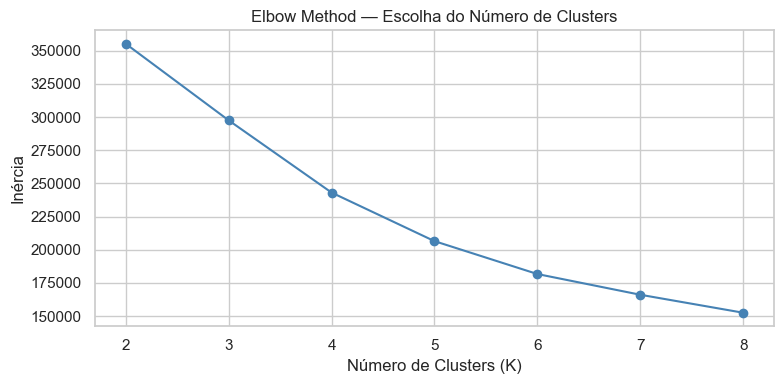

Analise o gráfico acima para escolher o K no ponto de inflexão (cotovelo).


In [4]:
features_cluster = df[[
    'discounted_price',
    'discount_percent',
    'rating',
    'rating_count',
    'preco_rel_categoria'
]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cluster)

# Elbow Method para escolher o K ótimo
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', color='steelblue')
ax.set_title('Elbow Method — Escolha do Número de Clusters')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inércia')
plt.tight_layout()
plt.show()
print('Analise o gráfico acima para escolher o K no ponto de inflexão (cotovelo).')

In [5]:
# K=4 mantido conforme hipótese dos 4 arquétipos
# Ajuste conforme resultado do Elbow Method
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

features_cluster = features_cluster.copy()
features_cluster['cluster'] = clusters
df.loc[features_cluster.index, 'cluster_produto'] = clusters

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters, sample_size=5000, random_state=42)
print(f'Silhouette Score (K={K_FINAL}): {sil_score:.3f}')
print('(Valores > 0.5 indicam clusters bem definidos; 0.25-0.5 = aceitável)')

Silhouette Score (K=4): 0.316
(Valores > 0.5 indicam clusters bem definidos; 0.25-0.5 = aceitável)


Perfil médio por cluster:
         discounted_price  discount_percent  rating  rating_count  \
cluster                                                             
0                  891.16             57.89    4.05        169.36   
1                 1263.81             19.31    4.38        161.40   
2                 5026.26             19.57    4.23         44.45   
3                  756.31             29.69    4.32      13989.19   

         preco_rel_categoria  n_produtos  
cluster                                   
0                       0.76       57512  
1                       1.17       28899  
2                       2.92        4605  
3                       0.81         333  


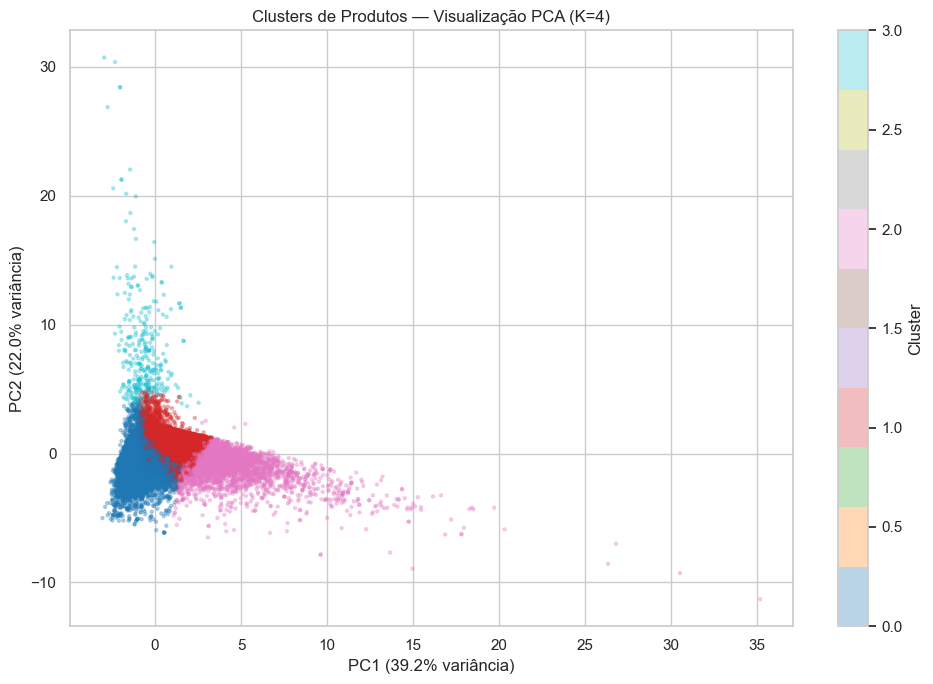

In [6]:
cluster_profile = features_cluster.groupby('cluster').mean().round(2)
cluster_profile['n_produtos'] = features_cluster.groupby('cluster').size()

print('Perfil médio por cluster:')
print(cluster_profile)

# Visualização PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters, cmap='tab10', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'Clusters de Produtos — Visualização PCA (K={K_FINAL})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
plt.tight_layout()
plt.show()

# 3. Regressão Explicativa (O que influencia o Rating?)

**Objetivo:** Entender quais variáveis explicam a avaliação do produto.

**Atenção:** Não buscamos previsão perfeita, mas **interpretação de relações**.

**Hipótese:** Preço e desconto têm efeito limitado; marca e contexto explicam mais.

**Métricas avaliadas:** R², RMSE, coeficientes padronizados.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
reg_features = df[[
    'discounted_price',
    'discount_percent',
    'preco_rel_categoria',
    'rating_count'
]].dropna()

y = df.loc[reg_features.index, 'rating']

X_train, X_test, y_train, y_test = train_test_split(
    reg_features, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
cv_r2 = cross_val_score(model, reg_features, y, cv=5, scoring='r2').mean()

print('=== Métricas da Regressão Linear ===')
print(f'R² (teste):              {r2:.4f}')
print(f'R² médio (CV 5-fold):   {cv_r2:.4f}')
print(f'RMSE (teste):            {rmse:.4f}')
print(f'\nInterpretação: O modelo explica {r2*100:.1f}% da variância do rating.')
print('Um R² baixo confirma a hipótese: preço e desconto sozinhos explicam pouco.')

coeficientes = pd.Series(model.coef_, index=reg_features.columns).sort_values(ascending=False)
print('\nCoeficientes:')
print(coeficientes)

=== Métricas da Regressão Linear ===
R² (teste):              0.0494
R² médio (CV 5-fold):   0.0483
RMSE (teste):            0.4436

Interpretação: O modelo explica 4.9% da variância do rating.
Um R² baixo confirma a hipótese: preço e desconto sozinhos explicam pouco.

Coeficientes:
preco_rel_categoria    0.034296
rating_count           0.000009
discounted_price      -0.000015
discount_percent      -0.004036
dtype: float64


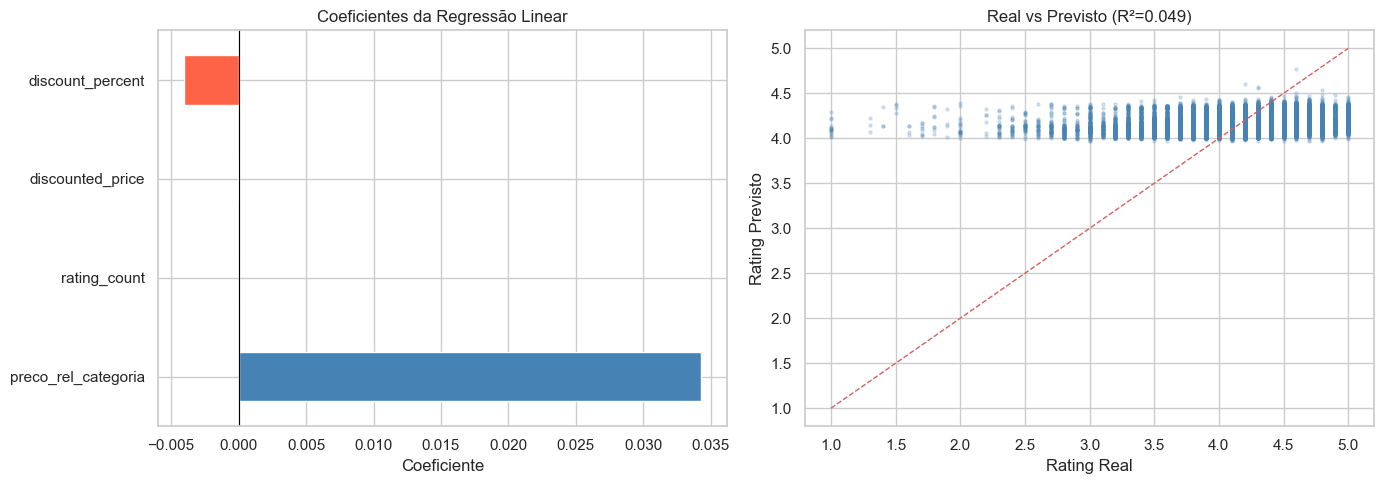

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coeficientes
coeficientes.plot(kind='barh', ax=axes[0], color=['tomato' if v < 0 else 'steelblue' for v in coeficientes])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coeficientes da Regressão Linear')
axes[0].set_xlabel('Coeficiente')

# Real vs Previsto
axes[1].scatter(y_test, y_pred, alpha=0.2, s=5, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
axes[1].set_xlabel('Rating Real')
axes[1].set_ylabel('Rating Previsto')
axes[1].set_title(f'Real vs Previsto (R²={r2:.3f})')

plt.tight_layout()
plt.show()

# 4. Classificação: Produto Bom vs Produto Fraco

**Definição:**
- Bom produto: `rating >= 4.5` e `rating_count >= mediana`
- Fraco: demais casos

**⚠️ Desbalanceamento:** A classe 'bom' é minoria (~13%). Usamos `class_weight='balanced'` para compensar.

**Métricas avaliadas:** Acurácia, Precision, Recall, F1-Score, AUC-ROC.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [11]:
df['produto_bom'] = (
    (df['rating'] >= 4.5) &
    (df['rating_count'] >= df['rating_count'].median())
).astype(int)

print(f'Distribuição da classe:')
print(df['produto_bom'].value_counts())
print(f'\nProporcao positivos: {df["produto_bom"].mean()*100:.1f}%')
print('Desbalanceamento detectado — usando class_weight=balanced')

clf_features = df[[
    'discounted_price',
    'discount_percent',
    'preco_rel_categoria'
]].dropna()

y_clf = df.loc[clf_features.index, 'produto_bom']

X_tr, X_te, y_tr, y_te = train_test_split(clf_features, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# class_weight='balanced' compensa o desbalanceamento
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_tr, y_tr)
y_te_pred = clf.predict(X_te)
y_te_proba = clf.predict_proba(X_te)[:, 1]

print('\n=== Relatório de Classificação ===')
print(classification_report(y_te, y_te_pred, target_names=['Fraco', 'Bom']))
print(f'AUC-ROC: {roc_auc_score(y_te, y_te_proba):.3f}')

Distribuição da classe:
produto_bom
0    83166
1     8183
Name: count, dtype: int64

Proporcao positivos: 9.0%
Desbalanceamento detectado — usando class_weight=balanced

=== Relatório de Classificação ===
              precision    recall  f1-score   support

       Fraco       0.94      0.69      0.80     16633
         Bom       0.14      0.53      0.23      1637

    accuracy                           0.68     18270
   macro avg       0.54      0.61      0.51     18270
weighted avg       0.87      0.68      0.74     18270

AUC-ROC: 0.636


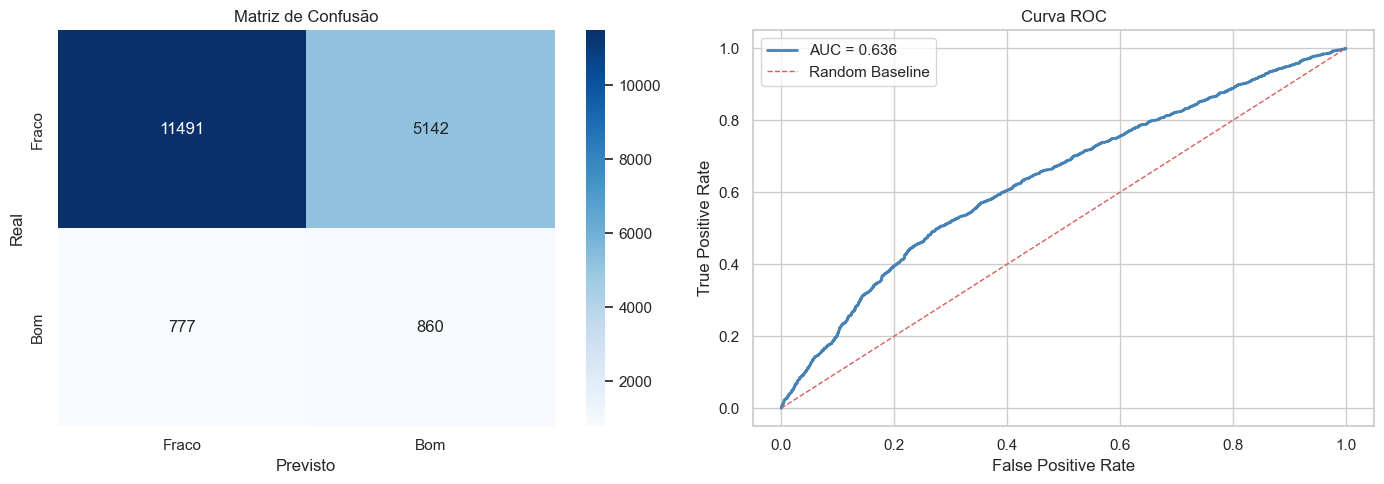

Importância das variáveis (coeficientes):
discounted_price      -0.000024
preco_rel_categoria   -0.008188
discount_percent      -0.023449
dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm = confusion_matrix(y_te, y_te_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fraco', 'Bom'], yticklabels=['Fraco', 'Bom'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

# Curva ROC
fpr, tpr, _ = roc_curve(y_te, y_te_proba)
auc = roc_auc_score(y_te, y_te_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1, label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Importâncias (coeficientes)
df.loc[clf_features.index, 'prob_produto_bom'] = clf.predict_proba(clf_features)[:, 1]
importancias = pd.Series(clf.coef_[0], index=clf_features.columns).sort_values(ascending=False)
print('Importância das variáveis (coeficientes):')
print(importancias)

# 5. Detecção de Anomalias

**Objetivo:** Encontrar produtos que fogem completamente do comportamento normal.

**Hipótese:** Anomalias representam:
- Preços inflacionados
- Descontos ineficazes
- Incoerência de posicionamento

**Parâmetro `contamination=0.05`:** assumimos que ~5% dos produtos são anomalias. Ajuste conforme contexto de negócio.

In [13]:
from sklearn.ensemble import IsolationForest

In [14]:
iso_features = df[[
    'discounted_price',
    'discount_percent',
    'rating',
    'rating_count'
]].dropna()

iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
anomaly_flag = iso.fit_predict(iso_features)

df.loc[iso_features.index, 'anomalia'] = anomaly_flag
n_anomalias = (anomaly_flag == -1).sum()
print(f'Anomalias detectadas: {n_anomalias:,} ({n_anomalias/len(iso_features)*100:.1f}%)')

# Comparação de médias
print('\nComparação Normal vs Anômalo:')
comp = df[df['anomalia'].notna()].groupby('anomalia')[[
    'discounted_price', 'discount_percent', 'rating', 'rating_count'
]].mean().round(2)
comp.index = comp.index.map({1: 'Normal', -1: 'Anomalia'})
print(comp)

Anomalias detectadas: 4,568 (5.0%)

Comparação Normal vs Anômalo:
          discounted_price  discount_percent  rating  rating_count
anomalia                                                          
Anomalia           3335.35             32.98    3.74       2099.48
Normal             1105.51             44.21    4.19        111.51


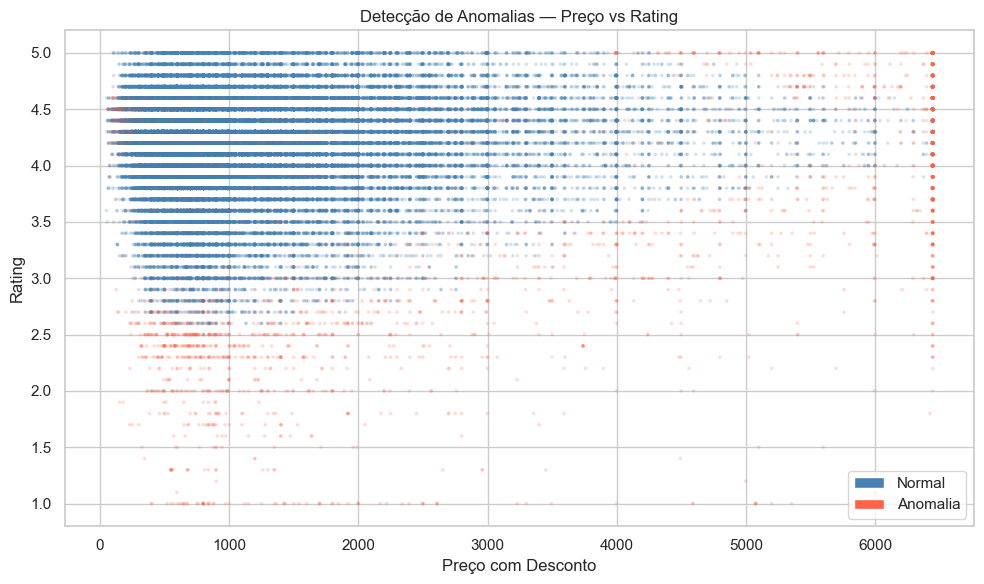


Amostra de anomalias:


,product_name,brand_name,discounted_price,discount_percent,rating,rating_count
13,Croc Textured Handheld Bag,Accessorize,5886,15,4.6,67
45,Women Relaxed Fit High-Rise Jeans,ONLY,2959,20,1.3,3
59,Women Relaxed Fit High-Rise Jeans,ONLY,2959,20,1.3,3
146,Men Regular Running Shoes,ASIAN,649,35,2.6,7
153,Men Regular Running Shoes,ASIAN,649,35,2.6,7
162,Mattifying Face Toner 120 ml,Biotique,220,0,4.4,2200
190,Women Embroidered Kurta Set,Jaipur Kurti,1147,55,3.9,2300
200,Multi Striped Casual Shirt,MANGO,3590,0,3.5,6


In [15]:
# Visualização das anomalias
df_plot_iso = df[df['anomalia'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 6))
colors = df_plot_iso['anomalia'].map({1: 'steelblue', -1: 'tomato'})
ax.scatter(
    df_plot_iso['discounted_price'].clip(upper=df_plot_iso['discounted_price'].quantile(0.99)),
    df_plot_iso['rating'],
    c=colors, alpha=0.15, s=3
)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Normal'),
                   Patch(facecolor='tomato', label='Anomalia')]
ax.legend(handles=legend_elements)
ax.set_xlabel('Preço com Desconto')
ax.set_ylabel('Rating')
ax.set_title('Detecção de Anomalias — Preço vs Rating')
plt.tight_layout()
plt.show()

print('\nAmostra de anomalias:')
df[df['anomalia'] == -1][[
    'product_name', 'brand_name', 'discounted_price', 'discount_percent', 'rating', 'rating_count'
]].head(8)

# 6. NLP Leve com Nome do Produto

**Objetivo:** Extrair significado semântico do nome do produto.

**Hipótese:** Certos termos (material, tipo, estilo) influenciam preço e avaliação.

> O dataset é de e-commerce indiano (Myntra), então nomes de produtos são predominantemente em inglês.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [17]:
df['product_name_clean'] = (
    df['product_name']
    .str.lower()
    .str.replace('[^a-z ]', '', regex=True)
    .str.strip()
)

# stop_words='english' é adequado pois o dataset é de e-commerce indiano com nomes em inglês
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=50,
    min_df=10,       # ignora termos muito raros
    max_df=0.8       # ignora termos muito comuns (aparecem em >80% dos produtos)
)

tfidf_matrix = tfidf.fit_transform(df['product_name_clean'].fillna(''))

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=df.index
)

print(f'Vocabulário TF-IDF: {len(tfidf.get_feature_names_out())} termos')
tfidf_df.head()

Vocabulário TF-IDF: 50 termos


,aline,analogue,bag,boys,bra,casual,collar,colourblocked,cotton,design,dress,dupatta,embroidered,ethnic,fit,floral,formal,girls,jacket,jeans,kurta,leather,maxi,men,neck,pack,palazzos,pants,polo,print,printed,pure,regular,round,saree,set,shirt,shoes,shorts,skinny,slim,sneakers,solid,straight,striped,trousers,tshirt,unisex,watch,women
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.488306,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.872672,0.0,0.0,0.0,0.0,0.0
2,0.733422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.510965,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.448337,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.403862,0.0,0.43976,0.0,0.0,0.0,0.0,0.513653,0.0,0.0,0.0,0.0,0.000000,0.0,0.616171,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
7,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.455199,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.89039,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


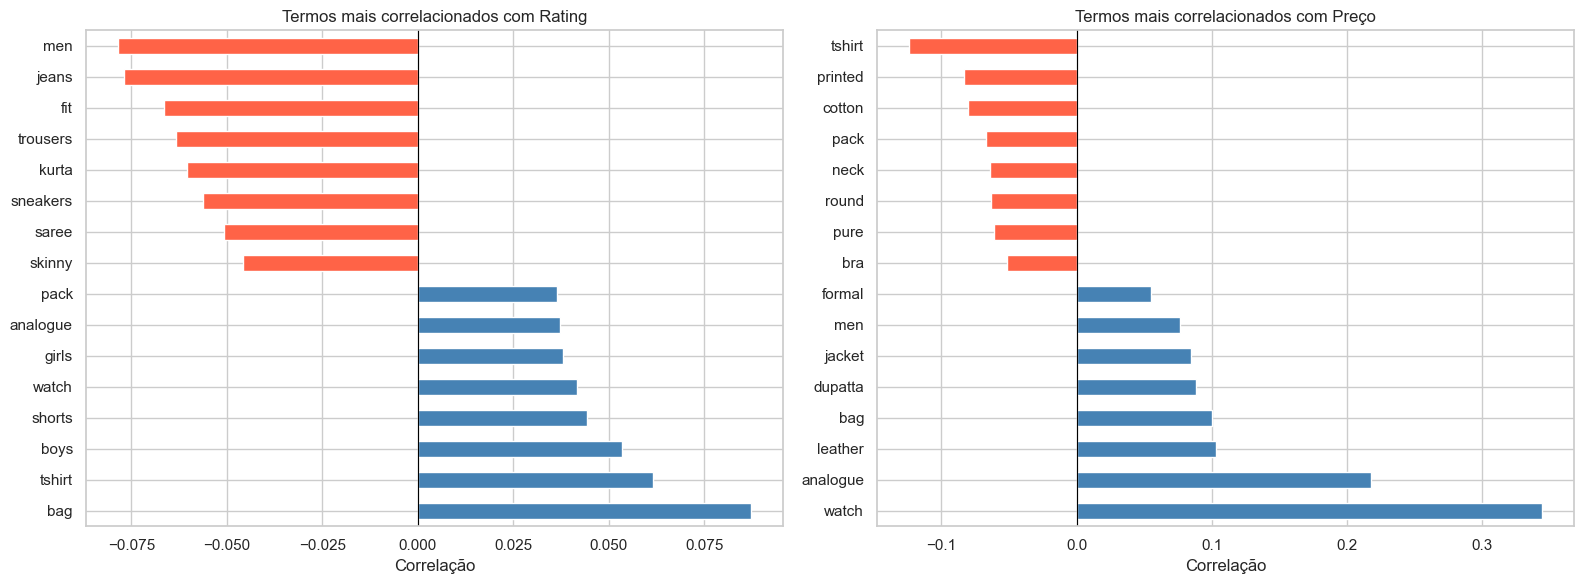

In [18]:
# Correlação dos termos com rating e preço
term_rating_corr = tfidf_df.corrwith(df['rating']).sort_values(ascending=False)
term_price_corr = tfidf_df.corrwith(df['discounted_price']).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top correlações com rating
top_rating = pd.concat([term_rating_corr.head(8), term_rating_corr.tail(8)])
colors_r = ['steelblue' if v > 0 else 'tomato' for v in top_rating]
top_rating.plot(kind='barh', ax=axes[0], color=colors_r)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Termos mais correlacionados com Rating')
axes[0].set_xlabel('Correlação')

# Top correlações com preço
top_price = pd.concat([term_price_corr.head(8), term_price_corr.tail(8)])
colors_p = ['steelblue' if v > 0 else 'tomato' for v in top_price]
top_price.plot(kind='barh', ax=axes[1], color=colors_p)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Termos mais correlacionados com Preço')
axes[1].set_xlabel('Correlação')

plt.tight_layout()
plt.show()

# 7. Consolidação Analítica

Neste ponto, a base enriquecida contém:

| Feature | Origem |
|---|---|
| `preco_rel_categoria` | Preço relativo à média da categoria |
| `zscore_preco_marca` | Posição do produto dentro da marca |
| `consistencia_marca` | Desvio padrão de rating da marca |
| `valor_percebido` | Rating × log(rating_count) / preço |
| `cluster_produto` | Segmento comportamental (KMeans) |
| `produto_bom` | Label binário de qualidade |
| `prob_produto_bom` | Probabilidade de sucesso (Logistic Reg.) |
| `anomalia` | Flag de produto atípico (Isolation Forest) |

**Essa base não é mais apenas descritiva — ela é interpretativa e acionável.**

**Próximos passos naturais:**
- Traduzir variáveis em narrativa visual no Power BI
- Usar `prob_produto_bom` como score de priorização de portfólio
- Investigar anomalias para identificar problemas de precificação
- Expandir regressão com variáveis de categoria e marca (encoding)

In [19]:
# Exportar base enriquecida
output_cols = [
    'product_name', 'brand_name', 'product_tag',
    'marked_price', 'discounted_price', 'discount_percent',
    'rating', 'rating_count',
    'preco_rel_categoria', 'zscore_preco_marca', 'consistencia_marca',
    'valor_percebido', 'cluster_produto', 'produto_bom',
    'prob_produto_bom', 'anomalia'
]

df_exportar = df[[c for c in output_cols if c in df.columns]]
df_exportar.to_csv('./dados/data_enriched.csv', index=False)
print(f'Base enriquecida exportada: ./dados/data_enriched.csv')
print(f'Shape: {df_exportar.shape}')
df_exportar.head()

Base enriquecida exportada: ./dados/data_enriched.csv
Shape: (91349, 16)


,product_name,brand_name,product_tag,marked_price,discounted_price,discount_percent,rating,rating_count,preco_rel_categoria,zscore_preco_marca,consistencia_marca,valor_percebido,cluster_produto,produto_bom,prob_produto_bom,anomalia
1,Men Striped Sliders,Mast & Harbour,flip-flops,1299,584,55,4.0,76,0.779974,-0.577239,0.417582,0.029752,0.0,0,0.408756,1.0
2,Printed A-line Kurta,Biba,kurtas,1999,1599,20,4.3,66,1.717419,-0.515707,0.429203,0.011307,1.0,0,0.603301,1.0
5,Floral Cotton Maxi Dress,Vishudh,dresses,4349,1826,58,4.1,800,1.548708,2.635534,0.308627,0.015012,0.0,0,0.383205,1.0
6,Fitted Crop Top,Tokyo Talkies,tops,499,249,50,4.4,210,0.336107,-1.498563,0.400887,0.094571,0.0,0,0.440266,1.0
7,Men Mesh Running Shoes,Woakers,sports-shoes,3125,687,78,3.4,591,0.385430,-0.579986,0.474728,0.031592,0.0,0,0.287467,1.0
